In [6]:
import os
import sys
import re
from pathlib import Path
from multiprocessing import Pool
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, skew, kurtosis

In [7]:
BASE_DIR = Path("/run/media/andres/2TB-Black/IDPAI/HPS1/Runs")
print(Path("/run/media/andres/2TB-Black/IDPAI/HPS1/Runs").exists())
OUTPUT_FILE = "idp_ml_dataset.parquet"  # Parquet format
NUM_CORES = os.cpu_count()
GRID_POINTS = np.linspace(0.0, 150, 450)

False


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_dataset_sanity_checks(df):
    # --- 0. Programmatic Alignment Check ---
    mismatches = df[df['sequence'].str.len() != df['seq_length']]
    print(f"[Data Integrity] Found {len(mismatches)} sequence length discrepancies.")
    
    # --- 1. Sequence Length Distribution Histogram ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df['seq_length'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title("Distribution of IDP Sequence Lengths", fontsize=13)
    ax.set_xlabel("Sequence Length ($N$)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("sanity_check_length_hist.png", dpi=300)
    print("Saved: sanity_check_length_hist.png")
    
    # --- 2. Flory Scaling Law Check (Rg vs. N) ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df['seq_length'], df['calculated_rg_mean'], color='darkgreen', alpha=0.5, label='Simulated IDPs')
    
    # Fit a power law trendline: log(Rg) = log(a) + nu * log(N)
    #Try fitting it with 0.34N^\alpha
    
    log_N = np.log(df['seq_length'])
    log_Rg = np.log(df['calculated_rg_mean'])
    nu, log_a = np.polyfit(log_N, log_Rg, 1)
    
    N_grid = np.linspace(df['seq_length'].min(), df['seq_length'].max(), 100)
    Rg_fit = np.exp(log_a) * (N_grid ** nu)
    ax.plot(N_grid, Rg_fit, color='red', linestyle='--', linewidth=2, 
            label=f"Fit: $R_g \\propto N^{{{nu:.3f}}}$")
    
    ax.set_title(r"Flory Scaling Law Sanity Check ($R_g$ vs. $N$)", fontsize=13)
    ax.set_xlabel("Sequence Length ($N$)", fontsize=11)
    ax.set_ylabel("Mean $R_g$ [nm]", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("sanity_check_flory_scaling.png", dpi=300)
    print("Saved: sanity_check_flory_scaling.png")

    # --- 3. MD Trajectory Sampling Depth Check (Total Frames) ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df['total_frames'], bins=15, color='gold', edgecolor='black', alpha=0.7)
    ax.set_title("MD Sampling Depth Check (Total Frames)", fontsize=13)
    ax.set_xlabel("Total Frames Sampled", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("sanity_check_total_frames.png", dpi=300)
    print("Saved: sanity_check_total_frames.png")

    # --- 4. Polymer Physics Structural Shape Factor Check ---
    # Calculate exact mean squared Rg using: <Rg^2> = <Rg>^2 + sigma^2
    rg_sq_mean = (df['calculated_rg_mean'] ** 2) + (df['calculated_rg_std'] ** 2)
    ratio = df['mean_r_end_sq'] / rg_sq_mean
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df['seq_length'], ratio, color='purple', alpha=0.5, label='Simulated Chains')
    ax.axhline(6.0, color='black', linestyle='-', linewidth=1.5, label='Ideal Linear Chain Limit (6.0)')
    ax.axhline(6.4, color='orange', linestyle='--', linewidth=1.5, label='Self-Avoiding Walk Limit (~6.4)')
    
    ax.set_title(r"Polymer Shape Factor Check ($\langle R_e^2 \rangle / \langle R_g^2 \rangle$)", fontsize=13)
    ax.set_xlabel("Sequence Length ($N$)", fontsize=11)
    ax.set_ylabel(r"Ratio $\langle R_e^2 \rangle / \langle R_g^2 \rangle$", fontsize=11)
    ax.set_ylim(2, 10)  # Magnify the region of physical expectations
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("sanity_check_polymer_ratio.png", dpi=300)
    print("Saved: sanity_check_polymer_ratio.png")

In [9]:
def parse_parameters(folder_path):
    """
    Parses the parameter block if it lives inside a file in the folder.
    Assumes it might be in config_stat.dat, a README, or a param file.
    Adjust the 'filename' below to wherever that text block lives.
    """
    param_file = folder_path / "System_Parameters.dat" 
    params = {}
    
    if not param_file.exists():
        return params
        
    try:
        with open(param_file, 'r') as f:
            content = f.read()
            
            # Regex to find key-value pairs (e.g., "Ionic concentration (M): 0.150000")
            # This extracts the numbers safely regardless of the exact text layout
            ionic = re.search(r"Ionic concentration.*:\s*([\d\.]+)", content)
            kappa = re.search(r"Yukawa kappa.*:\s*([\d\.]+)", content)
            epsilon = re.search(r"Yukawa epsilon.*:\s*([\d\.]+)", content)
            bjerrum = re.search(r"Bjerrum length.*:\s*([\d\.]+)", content)
            temp = re.search(r"Temperature.*:\s*([\d\.]+)", content)
            
            params['ionic_concentration_M'] = float(ionic.group(1)) if ionic else 0.15
            params['yukawa_kappa_nm_inv'] = float(kappa.group(1)) if kappa else 1.273787
            params['yukawa_epsilon_kcal_mol'] = float(epsilon.group(1)) if epsilon else 0.423234
            params['bjerrum_length_nm'] = float(bjerrum.group(1)) if bjerrum else 0.714697
            params['temperature_K'] = float(temp.group(1)) if temp else 298.0
    except Exception:
        # Fallback to defaults if parsing fails for a specific file
        pass
        
    return params

def process_single_folder(folder_path):
    """Worker function to completely parse a single simulation folder."""
    try:
        # 1. Read Sequence
        seq_file = folder_path / "OneLetterCode.dat"
        if not seq_file.exists():
            return None
        with open(seq_file, 'r') as f:
            sequence = "".join([line.strip() for line in f if line.strip()])

        # 2. Read config_stat.dat metrics
        config_file = folder_path / "config_stat.dat"
        config_data = np.loadtxt(config_file, comments="#")
        if config_data.ndim > 1: 
            config_data = config_data[0] # Fallback if multiple rows exist
            
        particle_n = int(config_data[0])
        persistence_length = config_data[2]  # <Lp>
        r_end_sq = config_data[3]            # <Rend2>
        avg_rg_config = config_data[4]       # <Rg>

        # 3. Read running_stat.dat (All Rg frames)
        running_file = folder_path / "running_stat.dat"
        rg_values = np.loadtxt(running_file, comments="#", usecols=2)
        if rg_values.ndim == 0:
            rg_values = np.array([rg_values])

        # 4. Statistical Moments of the Distribution
        total_frames = len(rg_values)
        rg_mean = np.mean(rg_values)
        rg_std = np.std(rg_values)
        rg_skew = skew(rg_values)
        rg_kurt = kurtosis(rg_values)

        # 5. Kernel Density Estimation (The Distogram)
        kde = gaussian_kde(rg_values)
        kde_distogram = kde.evaluate(GRID_POINTS)

        # 6. Parse Environmental Constants
        env_params = parse_parameters(folder_path)

        # 7. Combine everything into a master dictionary
        result = {
            "folder_id": folder_path.name,
            "sequence": sequence,
            "seq_length": particle_n,
            "persistence_length_lp": persistence_length,
            "mean_r_end_sq": r_end_sq,
            "config_avg_rg": avg_rg_config,
            "total_frames": total_frames,
            "calculated_rg_mean": rg_mean,
            "calculated_rg_std": rg_std,
            "calculated_rg_skew": rg_skew,
            "calculated_rg_kurtosis": rg_kurt,
            "rg_distogram": kde_distogram.tolist(),  # Must be list for Pandas -> Parquet export
        }
        
        # Merge the environmental parameters into the dictionary
        result.update(env_params)
        return result

    except Exception as e:
        print(f"Error in folder {folder_path.name}: {e}", file=sys.stderr)
        return None

In [27]:

print("Scanning directories...")
all_folders = [f for f in BASE_DIR.iterdir() if f.is_dir() and f.name.isdigit()]
print(f"Found {len(all_folders)} folders to parse.")
names = [a.name for a in all_folders]
arr = np.array(names)
nums = arr.astype(int)
nums.sort()
print(nums)
print(nums.shape)


Scanning directories...
Found 4783 folders to parse.
[   1    2    3 ... 9697 9698 9699]
(4783,)


In [28]:
print(f"Spinning up {NUM_CORES} CPU processes...")
results = []

with Pool(processes=NUM_CORES) as pool:
    # Using imap_unordered + chunksize to efficiently manage memory over 10k directories
    for res in pool.imap_unordered(process_single_folder, all_folders, chunksize=15):
        if res is not None:
            results.append(res)
            
        if len(results) % 500 == 0 and len(results) > 0:
            print(f"Progress: Captured {len(results)} / {len(all_folders)} datasets...")            

print("Building Dataframe...")
df = pd.DataFrame(results)

df["folder_id"] = df["folder_id"].astype(int)
df = df.sort_values("folder_id").reset_index(drop=True)
print(f"Writing dataset to Parquet format -> {OUTPUT_FILE}")
# engine='pyarrow' handles the nested float arrays perfectly
df.to_parquet(OUTPUT_FILE, engine='pyarrow', index=False)
print("Extraction successful! 2TB processed and packed.")

Spinning up 20 CPU processes...
Progress: Captured 500 / 4783 datasets...
Progress: Captured 1000 / 4783 datasets...


/tmp/ipykernel_58887/521179631.py:48: UserWarning: loadtxt: input contained no data: "/run/media/andres/2TB-Black/IDPAI/HPS1/Runs/2233/config_stat.dat"
  config_data = np.loadtxt(config_file, comments="#")
Error in folder 2233: index 0 is out of bounds for axis 0 with size 0


Progress: Captured 1500 / 4783 datasets...
Progress: Captured 2000 / 4783 datasets...
Progress: Captured 2500 / 4783 datasets...
Progress: Captured 3000 / 4783 datasets...
Progress: Captured 3500 / 4783 datasets...


Error in folder 9015: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9015/config_stat.dat not found.
Error in folder 9071: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9071/config_stat.dat not found.
Error in folder 9072: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9072/config_stat.dat not found.
Error in folder 9031: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9031/config_stat.dat not found.
Error in folder 887: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/887/running_stat.dat not found.
Error in folder 890: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/890/running_stat.dat not found.
Error in folder 9005: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9005/config_stat.dat not found.
Error in folder 9080: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9080/config_stat.dat not found.
Error in folder 9065: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9065/config_stat.dat not found.
Error in folder 9025: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9025/config_stat.dat not found.
Error in folder 9115: 

Progress: Captured 4000 / 4783 datasets...


Error in folder 9212: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9212/config_stat.dat not found.
Error in folder 9282: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9282/config_stat.dat not found.
Error in folder 9323: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9323/config_stat.dat not found.
Error in folder 9325: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9325/config_stat.dat not found.
Error in folder 9180: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9180/config_stat.dat not found.
Error in folder 9405: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9405/config_stat.dat not found.
Error in folder 9463: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9463/config_stat.dat not found.
Error in folder 9238: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9238/config_stat.dat not found.
Error in folder 9437: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9437/config_stat.dat not found.
Error in folder 9266: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9266/config_stat.dat not found.
Error in folder 9412

Progress: Captured 4500 / 4783 datasets...


Error in folder 9676: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9676/config_stat.dat not found.
Error in folder 9691: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9691/config_stat.dat not found.
Error in folder 9664: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9664/config_stat.dat not found.
Error in folder 9638: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9638/config_stat.dat not found.
Error in folder 9614: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9614/config_stat.dat not found.


Building Dataframe...
Writing dataset to Parquet format -> idp_ml_dataset.parquet
Extraction successful! 2TB processed and packed.


Loading Parquet dataset...
[Data Integrity] Found 0 sequence length discrepancies.
Saved: sanity_check_length_hist.png
Saved: sanity_check_flory_scaling.png
Saved: sanity_check_total_frames.png
Saved: sanity_check_polymer_ratio.png
Successfully loaded dataset with 4743 rows and 17 columns.

Exporting the first 5 rows to dataset_preview.csv...
CSV preview created! You can open this file to check your sequence/parameter alignments.

Generating histograms for the first few rows...
Plot saved successfully as 'idp_rg_distributions.png'!


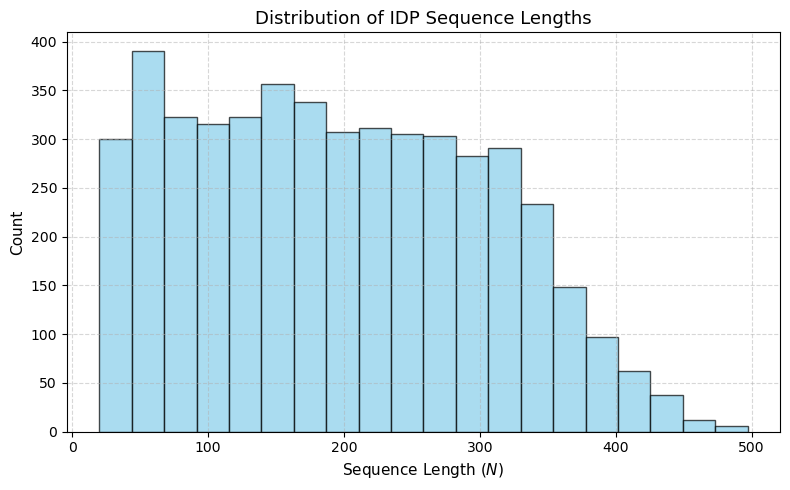

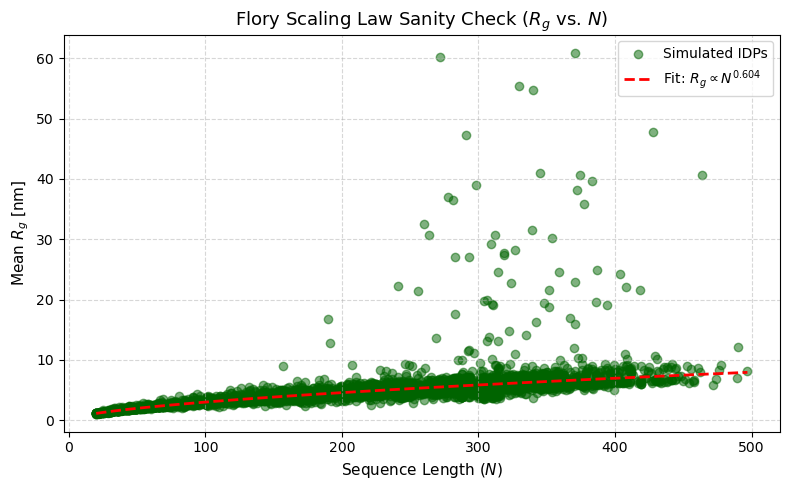

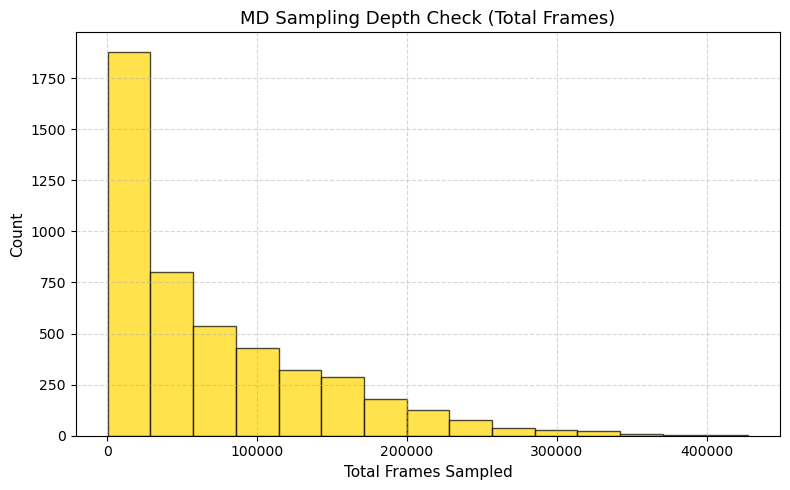

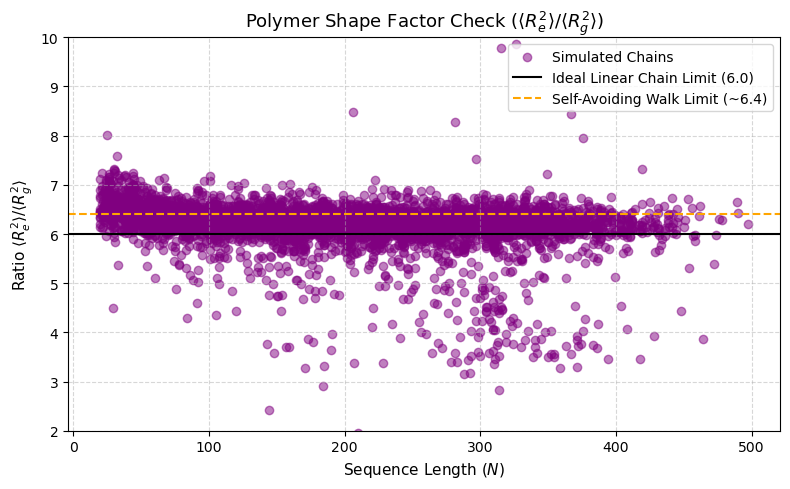

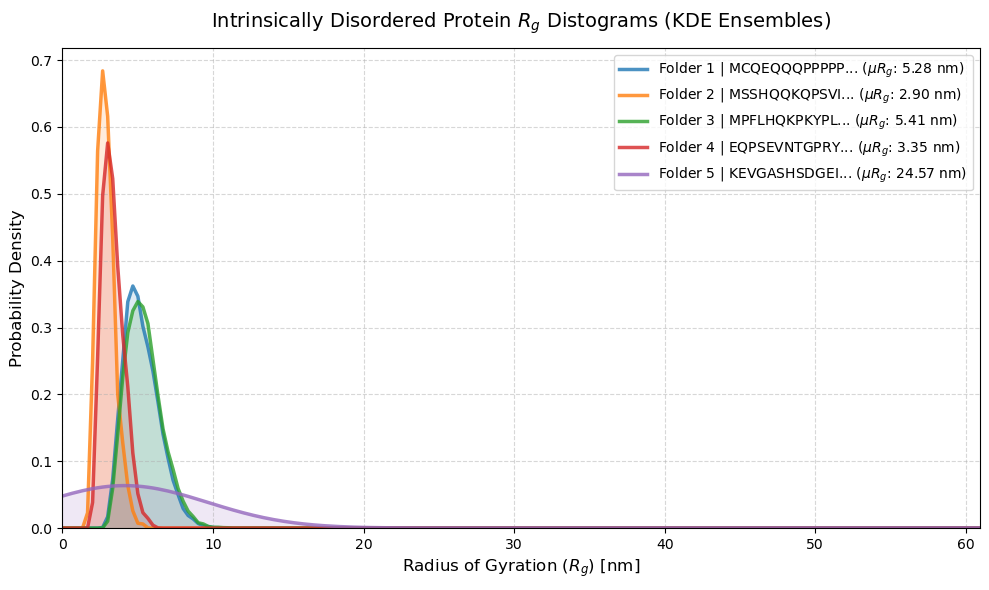

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
INPUT_FILE = "idp_ml_dataset.parquet"
CSV_SNIPPET_FILE = "dataset_preview.csv"

# Recreate the exact evaluation grid used during the parsing step
# (Make sure these match your parsing script settings: 0 to 30nm, 300 points)
def main():
    if not Path(INPUT_FILE).exists():
        print(f"Error: Could not find {INPUT_FILE} in the current directory.")
        return

    print("Loading Parquet dataset...")
    df = pd.read_parquet(INPUT_FILE)
    run_dataset_sanity_checks(df)
    print(f"Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

    # ---------------------------------------------------------
    # PART 1: EXPORT A CLEAN CSV PREVIEW
    # ---------------------------------------------------------
    print(f"\nExporting the first 5 rows to {CSV_SNIPPET_FILE}...")
    
    # We take a slice of the first 5 rows
    df_preview = df.head(5).copy()
    
    # Crucial step: The 'rg_distogram' column holds a 300-element list. 
    # Storing this raw list makes the CSV messy. Let's truncate it to a string 
    # preview just for the CSV file so it's clean to look at.
    df_preview['rg_distogram'] = df_preview['rg_distogram'].apply(
        lambda x: f"[{x[0]:.4f}, {x[1]:.4f}, ..., {x[-1]:.4f}] (Len: {len(x)})"
    )
    
    # Save the preview snippet
    df_preview.to_csv(CSV_SNIPPET_FILE, index=False)
    print("CSV preview created! You can open this file to check your sequence/parameter alignments.")

    # ---------------------------------------------------------
    # PART 2: PLOT HISTOGRAMS (DISTOGRAM ENSEMBLES)
    # ---------------------------------------------------------
    print("\nGenerating histograms for the first few rows...")
    
    # Let's plot the first 3 sequences to see how their Rg distributions compare
    num_to_plot = min(5, len(df))
    
    plt.figure(figsize=(10, 6))
    
    for i in range(num_to_plot):
        row = df.iloc[i]
        folder_id = row['folder_id']
        sequence = row['sequence']
        mean_rg = row['calculated_rg_mean']
        
        # Grab the distogram vector
        distogram = np.array(row['rg_distogram'])
        
        # Shorten the sequence string if it's too long for the legend label
        seq_label = sequence if len(sequence) <= 15 else f"{sequence[:12]}..."
        
        # Plot the continuous density over our defined spatial grid
        plt.plot(
            GRID_POINTS, 
            distogram, 
            label=f"Folder {folder_id} | {seq_label} ($\mu R_g$: {mean_rg:.2f} nm)", 
            linewidth=2.5,
            alpha=0.8
        )
        
        # Fill the area under the curve for visual clarity
        plt.fill_between(GRID_POINTS, distogram, alpha=0.15)

    # Styling the plot for physical data
    plt.title("Intrinsically Disordered Protein $R_g$ Distograms (KDE Ensembles)", fontsize=14, pad=15)
    plt.xlabel("Radius of Gyration ($R_g$) [nm]", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.xlim(0, max(df['calculated_rg_mean'].max(), 15.0)) # Dynamically scale X axis
    plt.ylim(bottom=0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=10, loc="upper right")
    plt.tight_layout()
    
    # Save and display
    plt.savefig("idp_rg_distributions.png", dpi=300)
    print("Plot saved successfully as 'idp_rg_distributions.png'!")
    plt.show()

if __name__ == "__main__":
    main()

Loading Parquet dataset...
Original dataset shape: (4743, 17)
Rows after filtering by sampling depth: 3691
Final clean dataset shape: 3521 rows
[Data Integrity] Found 0 sequence length discrepancies.
Saved: sanity_check_length_hist.png
Saved: sanity_check_flory_scaling.png
Saved: sanity_check_total_frames.png
Saved: sanity_check_polymer_ratio.png


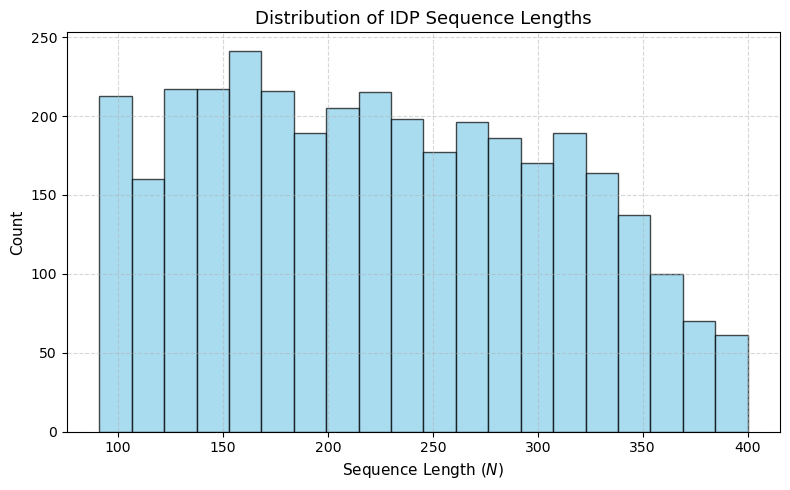

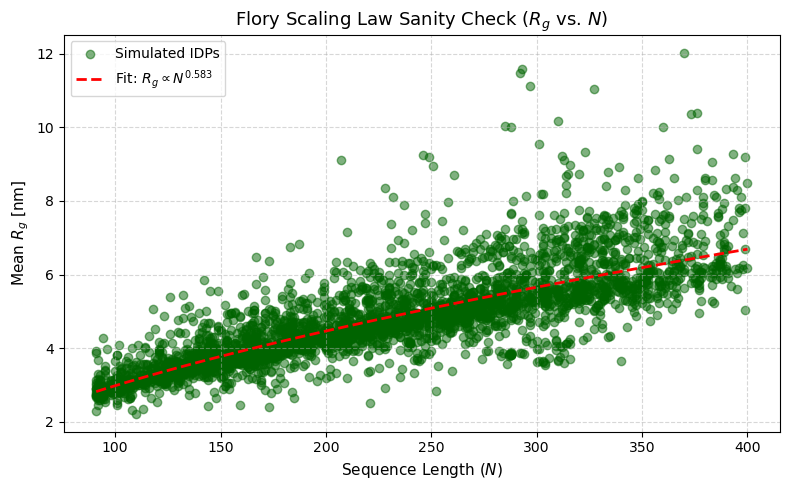

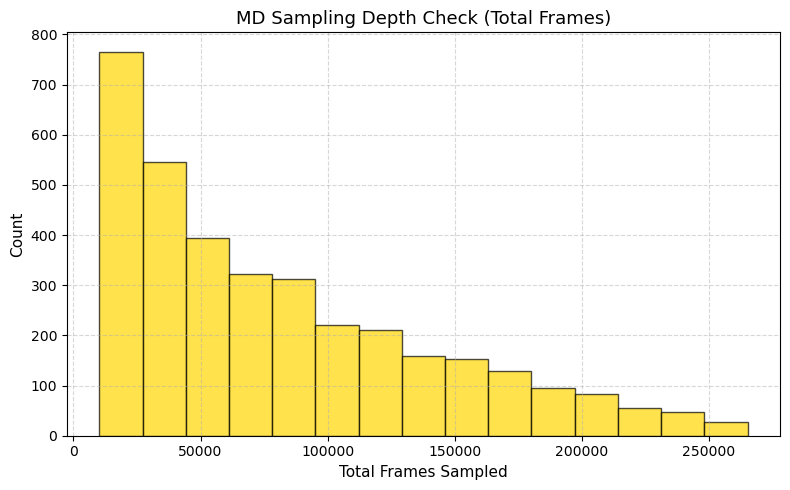

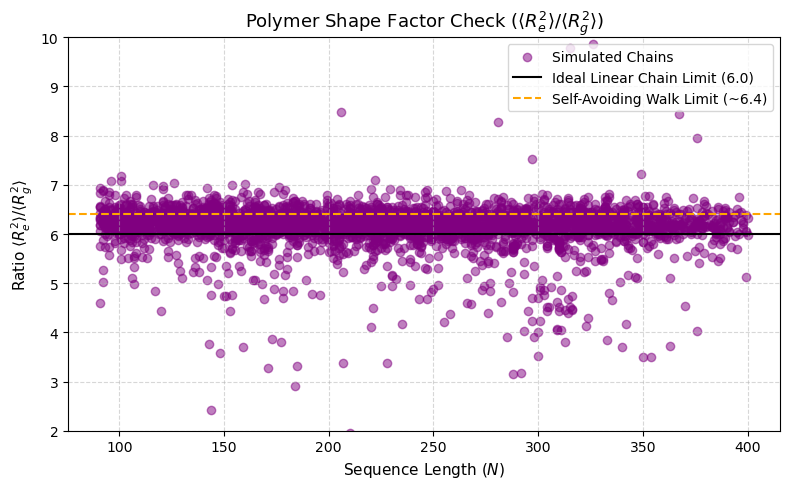

In [15]:
if not Path(INPUT_FILE).exists():
    print(f"Error: Could not find {INPUT_FILE} in the current directory.")

print("Loading Parquet dataset...")
df = pd.read_parquet(INPUT_FILE)
print(f"Original dataset shape: {df.shape}")

# --- Step 1: Filter by Sampling Depth ---
# Drop simulations that fall well below your target frame count
# (Adjust the threshold based on your 'total_frames' histogram)
frame_threshold = 10000  # Example threshold
df_clean = df[df['total_frames'] >= frame_threshold].copy()
print(f"Rows after filtering by sampling depth: {df_clean.shape[0]}")

# --- Step 2: Filter by Flory Scaling Outliers ---
# Calculate the residuals from your Flory line to find statistical anomalies
log_N = np.log(df_clean['seq_length'])
log_Rg = np.log(df_clean['calculated_rg_mean'])

# Re-fit the line on the majority data
nu, log_a = np.polyfit(log_N, log_Rg, 1)

# Predict what Rg *should* be according to the fit
log_Rg_pred = log_a + nu * log_N
residuals = log_Rg - log_Rg_pred

# Use standard deviation of the residuals to identify outliers
# Dropping rows further than 3 standard deviations away (or a strict manual threshold)
residual_std = residuals.std()
df_clean = df_clean[np.abs(residuals) <= 3 * residual_std]
df_clean = df_clean[df_clean['seq_length'] <= 400]  # Ensure no zero-length sequences remain
print(f"Final clean dataset shape: {df_clean.shape[0]} rows")
run_dataset_sanity_checks(df_clean)

Extremes plotted successfully! Saved as 'idp_rg_extremes.png'


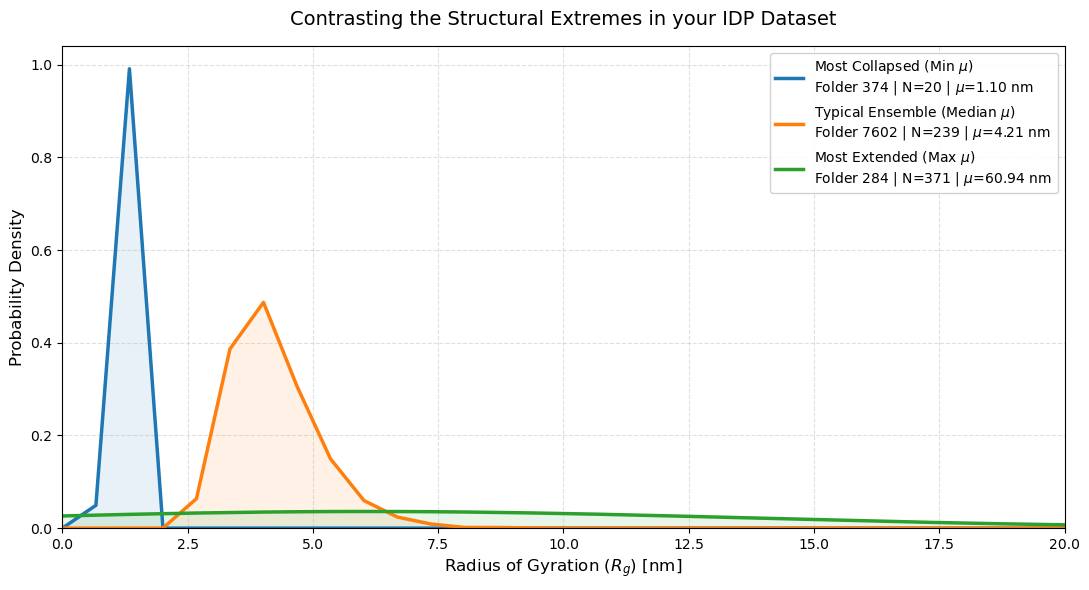

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




# 1. Sort the dataframe by the calculated mean Rg to easily grab statistics
df_sorted = df.sort_values("calculated_rg_mean").reset_index(drop=True)

# 2. Extract the three target rows
row_min = df_sorted.iloc[0]                  # Lowest Mean Rg (Most Collapsed)
row_max = df_sorted.iloc[-1]                 # Highest Mean Rg (Most Extended)
row_mid = df_sorted.iloc[len(df_sorted) // 2] # Median Mean Rg (The Average Joes)


# Put them in a dictionary for easy looping
extremes = {
    "Most Collapsed (Min $\mu$)": row_min,
    "Typical Ensemble (Median $\mu$)": row_mid,
    "Most Extended (Max $\mu$)": row_max
}

# 3. Plotting
GRID_POINTS = np.linspace(0.0,200, 300) 
plt.figure(figsize=(11, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"] # Clean contrasting colors

for (label, row), color in zip(extremes.items(), colors):
    folder_id = row['folder_id']
    seq_len = row['seq_length']
    mean_rg = row['calculated_rg_mean']
    distogram = np.array(row['rg_distogram'])
    
    # Format a clean legend label
    legend_text = f"{label}\nFolder {folder_id} | N={seq_len} | $\mu$={mean_rg:.2f} nm"
    
    # Plot the line
    plt.plot(GRID_POINTS, distogram, label=legend_text, color=color, linewidth=2.5)
    plt.fill_between(GRID_POINTS, distogram, color=color, alpha=0.1)

# Styling
plt.title("Contrasting the Structural Extremes in your IDP Dataset", fontsize=14, pad=15)
plt.xlabel("Radius of Gyration ($R_g$) [nm]", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

# Dynamic X-axis limit based on the maximum Rg found
plt.xlim(0, 20)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=10, loc="upper right", framealpha=0.9)
plt.tight_layout()

# Save the high-contrast plot
plt.savefig("idp_rg_extremes.png", dpi=300)
print("Extremes plotted successfully! Saved as 'idp_rg_extremes.png'")
plt.show()

In [2]:
# Load your full parsed dataset
df = pd.read_parquet("idp_ml_dataset.parquet")
target_seq = "ATSTKKLHKEPATLIKAIDGDTVKLMYKGQPMTFRLLLVDTPETKHPKKGVEKYGPEASAFTKKMVENAKKIEVEFDKGQRTDKYGRGLAYIYADGKMVNEALVRQGLAKVAYVYKPNNTHEQHLRKSEAQAKKEK" # Put the full string here

print(df.keys())
# Filter the DataFrame
asyn = df[df['sequence'] == target_seq]
if not asyn.empty:
    print(f"Found sequence in Folder: {asyn['folder_id'].values[0]}")
    print(asyn)
else:
    print("Sequence not found in the dataset.")

Index(['folder_id', 'sequence', 'seq_length', 'persistence_length_lp',
       'mean_r_end_sq', 'config_avg_rg', 'total_frames', 'calculated_rg_mean',
       'calculated_rg_std', 'calculated_rg_skew', 'calculated_rg_kurtosis',
       'rg_distogram', 'ionic_concentration_M', 'yukawa_kappa_nm_inv',
       'yukawa_epsilon_kcal_mol', 'bjerrum_length_nm', 'temperature_K'],
      dtype='object')
Sequence not found in the dataset.


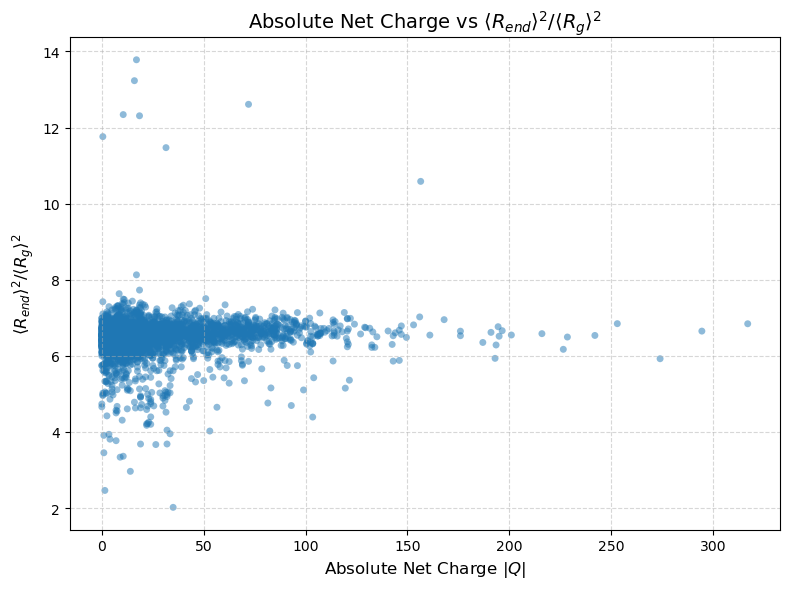

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1. Parameter Definitions (Provided by User) ───────────────────────
MASS = 0
CHARGE = 1
SIGMA = 2
HPS1 = 3
HPS2 = 4

AA_PARAMS = {
    "-": dict(mass=0.0, charge=0.0, sigma=0.0, HPS1=0.0, HPS2=0.0),  # Padding
    "A": dict(mass=71.08, charge=0.0, sigma=0.504, HPS1=0.730, HPS2=0.003),
    "R": dict(mass=156.20, charge=1.0, sigma=0.656, HPS1=0.000, HPS2=0.723),
    "N": dict(mass=114.10, charge=0.0, sigma=0.568, HPS1=0.432, HPS2=0.160),
    "D": dict(mass=115.10, charge=-1.0, sigma=0.558, HPS1=0.378, HPS2=0.002),
    "C": dict(mass=103.10, charge=0.0, sigma=0.548, HPS1=0.595, HPS2=0.400),
    "Q": dict(mass=128.10, charge=0.0, sigma=0.602, HPS1=0.514, HPS2=0.468),
    "E": dict(mass=129.10, charge=-1.0, sigma=0.592, HPS1=0.459, HPS2=0.022),
    "G": dict(mass=57.05, charge=0.0, sigma=0.450, HPS1=0.649, HPS2=0.784),
    "H": dict(mass=137.10, charge=0.5, sigma=0.608, HPS1=0.514, HPS2=0.487),
    "I": dict(mass=113.20, charge=0.0, sigma=0.618, HPS1=0.973, HPS2=0.687),
    "L": dict(mass=113.20, charge=0.0, sigma=0.618, HPS1=0.973, HPS2=0.335),
    "K": dict(mass=128.20, charge=1.0, sigma=0.636, HPS1=0.514, HPS2=0.095),
    "M": dict(mass=131.20, charge=0.0, sigma=0.618, HPS1=0.838, HPS2=0.993),
    "F": dict(mass=147.20, charge=0.0, sigma=0.636, HPS1=1.000, HPS2=0.871),
    "P": dict(mass=97.12, charge=0.0, sigma=0.556, HPS1=1.000, HPS2=0.471),
    "S": dict(mass=87.08, charge=0.0, sigma=0.518, HPS1=0.595, HPS2=0.487),
    "T": dict(mass=101.10, charge=0.0, sigma=0.562, HPS1=0.676, HPS2=0.274),
    "W": dict(mass=186.20, charge=0.0, sigma=0.678, HPS1=0.946, HPS2=0.753),
    "Y": dict(mass=163.20, charge=0.0, sigma=0.646, HPS1=0.865, HPS2=0.984),
    "V": dict(mass=99.07, charge=0.0, sigma=0.586, HPS1=0.892, HPS2=0.428),
}

ids = {aa: i for i, aa in enumerate(list(AA_PARAMS.keys()))}

# Using numpy for dataframe workflow compatibility (interchangeable with jnp)
param_matrix = np.array([
    [v["mass"], v["charge"], v["sigma"], v["HPS1"], v["HPS2"]] 
    for v in AA_PARAMS.values()
])

# ─── 2. Load Your Parquet Dataset ──────────────────────────────────────
# Replace with your actual path if necessary
df = pd.read_parquet('idp_ml_dataset.parquet') 
# ─── 3. Vectorized Absolute Charge Extraction ──────────────────────────
# Find the maximum sequence length to pad uniformly

# Sum across the sequence length axis and compute the absolute value

# ─── 4. Compute the Ratio <Rend>^2 / <Rg>^2 ───────────────────────────
# 'mean_r_end_sq' represents <Rend>^2. 
# 'calculated_rg_mean' (or 'config_avg_rg') represents <Rg>, so we square it.
df['rg_sq'] = df['calculated_rg_mean'] ** 2
df['ratio'] = df['mean_r_end_sq'] / df['rg_sq']
df = df[df['ratio'] <= 14]
max_len = df['sequence'].str.len().max()
padded_seqs = df['sequence'].str.ljust(max_len, '-')
seq_ids = np.array([[ids.get(aa, ids['-']) for aa in seq] for seq in padded_seqs])
# Extract the charge column via matrix indexing: shape will be (num_sequences, max_len)
charges_grid = param_matrix[seq_ids, CHARGE]
df['abs_charge'] = np.abs(charges_grid.sum(axis=1))


# Map characters to IDs safely (defaults to padding ID if an unknown character is found)

# ─── 5. Plotting ───────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# With ~4,500 points, alpha=0.5 helps reveal data density and prevents overplotting
plt.scatter(
    df['abs_charge'], 
    df['ratio'], 
    alpha=0.5, 
    color='#1f77b4', 
    edgecolors='none', 
    s=25
)

# Formatting with proper LaTeX labels
plt.xlabel(r'Absolute Net Charge $|Q|$', fontsize=12)
plt.ylabel(r'$\langle R_{end} \rangle^2 / \langle R_g \rangle^2$', fontsize=12)
plt.title(r'Absolute Net Charge vs $\langle R_{end} \rangle^2 / \langle R_g \rangle^2$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('charge_vs_rg_ratio.png', dpi=300)
plt.show()

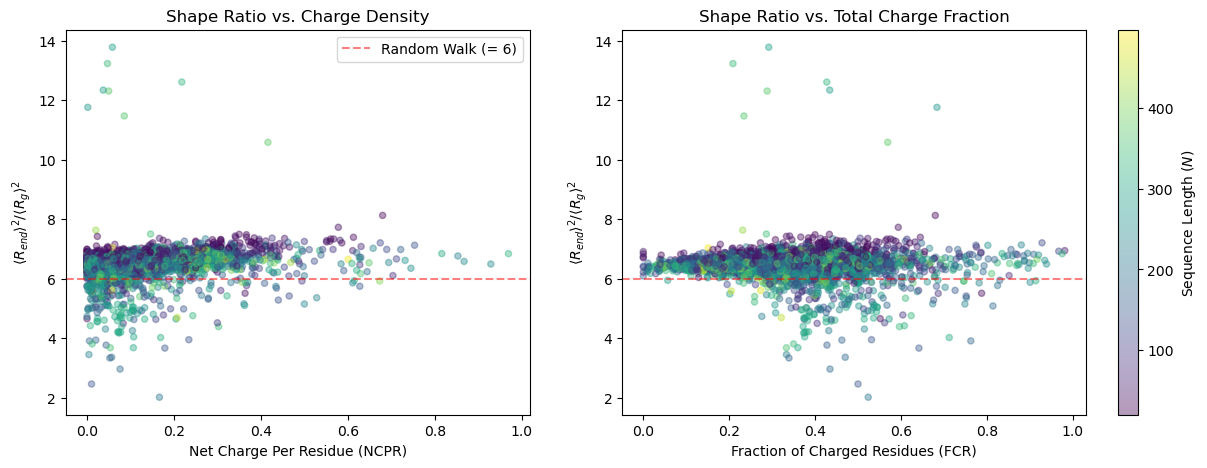

In [13]:
# Assuming 'df', 'param_matrix', and 'seq_ids' are already computed from the previous code...

# 1. Total absolute net charge |Q|
df['abs_charge'] = np.abs(param_matrix[seq_ids, CHARGE].sum(axis=1))

# 2. Length-Normalized Metrics
df['ncpr'] = df['abs_charge'] / df['seq_length']  # Net Charge Per Residue

# Calculate Fraction of Charged Residues (FCR)
# Counting how many residues have a non-zero charge per sequence
is_charged = param_matrix[seq_ids, CHARGE] != 0
df['fcr'] = is_charged.sum(axis=1) / df['seq_length']

# 3. Shape Ratio (Length-independent)
df['ratio'] = df['mean_r_end_sq'] / (df['calculated_rg_mean'] ** 2)

# 4. Plotting the Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: NCPR
sc1 = ax1.scatter(df['ncpr'], df['ratio'], alpha=0.4, c=df['seq_length'], cmap='viridis', s=20)
ax1.set_xlabel('Net Charge Per Residue (NCPR)')
ax1.set_ylabel(r'$\langle R_{end} \rangle^2 / \langle R_g \rangle^2$')
ax1.axhline(6.0, color='red', linestyle='--', alpha=0.5, label='Random Walk (= 6)')
ax1.set_title('Shape Ratio vs. Charge Density')
ax1.legend()

# Plot 2: FCR
sc2 = ax2.scatter(df['fcr'], df['ratio'], alpha=0.4, c=df['seq_length'], cmap='viridis', s=20)
ax2.set_xlabel('Fraction of Charged Residues (FCR)')
ax2.set_ylabel(r'$\langle R_{end} \rangle^2 / \langle R_g \rangle^2$')
ax2.axhline(6.0, color='red', linestyle='--', alpha=0.5)
ax2.set_title('Shape Ratio vs. Total Charge Fraction')

# Add a colorbar to double-check that sequence length features are completely mixed
cbar = fig.colorbar(sc2, ax=[ax1, ax2], orientation='vertical', fraction=0.03, pad=0.03)
cbar.set_label('Sequence Length ($N$)')

plt.savefig('normalized_idp_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

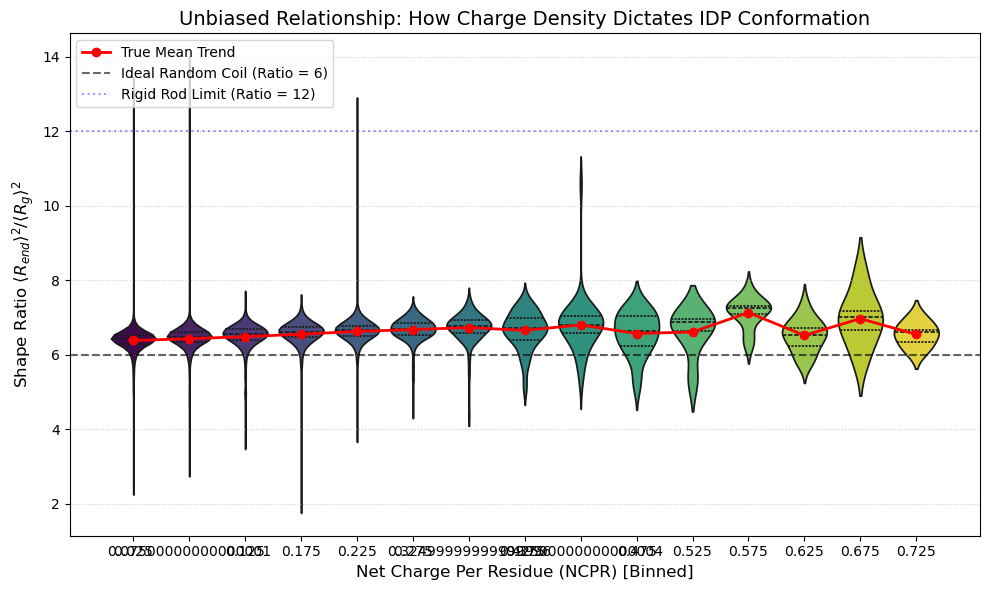

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' already contains 'ncpr' and 'ratio' from the previous step...

# 1. Define clean, uniform bins for your charge metric (NCPR)
# This ensures a sequence with NCPR=0.4 is evaluated fairly against the many sequences at NCPR=0.0
bin_width = 0.05
bins = np.arange(0, df['ncpr'].max() + bin_width, bin_width)
df['ncpr_bin'] = pd.cut(df['ncpr'], bins=bins)

# Filter out bins that have extremely few points (e.g., < 5) to avoid huge statistical noise at the tails
bin_counts = df['ncpr_bin'].value_counts()
valid_bins = bin_counts[bin_counts >= 5].index
df_filtered = df[df['ncpr_bin'].isin(valid_bins)].copy()

# Convert bins to their midpoint float values for clean plotting
df_filtered['bin_midpoint'] = df_filtered['ncpr_bin'].apply(lambda x: x.mid if pd.notnull(x) else np.nan).astype(float)

# 2. Plotting to reveal the unbiased relationship
plt.figure(figsize=(10, 6))

# Use a violin plot or boxplot to see the true distribution shape per charge tier
sns.violinplot(
    data=df_filtered,
    x='bin_midpoint',
    y='ratio',
    hue='bin_midpoint', # Added to satisfy modern seaborn syntax
    palette='viridis',
    inner='quartile',
    legend=False
)

# Overlay a trendline of the mean values across the bins
bin_means = df_filtered.groupby('bin_midpoint')['ratio'].mean()
plt.plot(np.arange(len(bin_means)), bin_means.values, color='red', marker='o', linewidth=2, label='True Mean Trend')

# Physical reference lines
plt.axhline(6.0, color='black', linestyle='--', alpha=0.6, label='Ideal Random Coil (Ratio = 6)')
plt.axhline(12.0, color='blue', linestyle=':', alpha=0.4, label='Rigid Rod Limit (Ratio = 12)')

# Formatting
plt.xlabel('Net Charge Per Residue (NCPR) [Binned]', fontsize=12)
plt.ylabel(r'Shape Ratio $\langle R_{end} \rangle^2 / \langle R_g \rangle^2$', fontsize=12)
plt.title('Unbiased Relationship: How Charge Density Dictates IDP Conformation', fontsize=14)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('unbiased_charge_vs_ratio.png', dpi=300)
plt.show()

In [4]:
# Isolate the extreme outliers
outliers = df[df['ratio'] > 15]

print(f"Number of impossible outlier sequences: {len(outliers)}")
print("\nChecking statistical profiles of outliers:")
print(outliers[['total_frames', 'calculated_rg_skew', 'calculated_rg_kurtosis']].describe())

# Check if sequence length or box dimensions correlate with the issue
# (If it's a PBC issue, shorter chains in large boxes might escape it, while long chains fail)

Number of impossible outlier sequences: 79

Checking statistical profiles of outliers:
        total_frames  calculated_rg_skew  calculated_rg_kurtosis
count      79.000000           79.000000               79.000000
mean   163645.911392            5.884707               60.383947
std     59969.353864            4.817683              120.897032
min     33880.000000            1.891350                1.917763
25%    128716.000000            2.940543                7.160771
50%    155674.000000            4.068964               15.091686
75%    200154.000000            6.950466               48.407033
max    367544.000000           22.348293              580.150334


- plot lenght distribution of whole dataset and show some Rg distributions for sanity check 
if theres noise or bad runs filter them out before training network

- after training run known proteins through network to check 

- its better to have a flat sample distribution in regards to lenght so if the distribution is not flat 
